# Kernel Trick SVM

In [50]:
import numpy as np  # Used for math and working with arrays/numbers
import pandas as pd # Used for working with tables/dataframes
import matplotlib.pyplot as plt # Used to draw graphs and charts
from matplotlib.colors import ListedColormap # Tool to create custom color maps (e.g., red/blue for classes)
from matplotlib.axes._axes import _log as matplotlib_axes_logger # Internal logger used to suppress warning messages
from mpl_toolkits import mplot3d # 3D plotting support for Matplotlib
from sklearn.model_selection import train_test_split # Function to split data into training and testing sets
from sklearn.svm import SVC  #  model that finds best boundary between classes

In [51]:
# Function that generates circular/ring-shaped fake data — two classes arranged in concentric circles
from sklearn.datasets import make_circles

# Factor=0.1 : makes the inner circle very small compared to the outer one
# Noise=0.1 : adds a little randomness so points aren't perfectly circular
# X-coordinates (x,y position) of each point,  y-label (0 or 1 — which circle it belongs to)
X,y = make_circles(100, factor=.1, noise=.1) # 100 data points

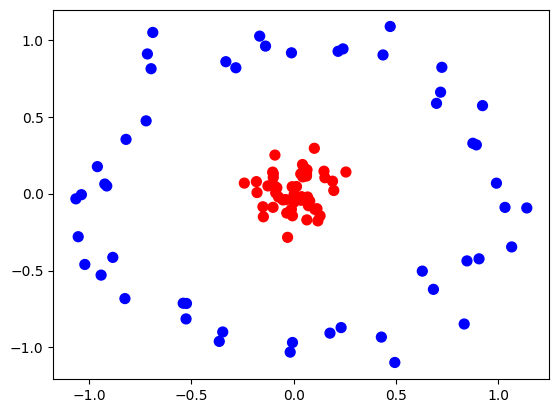

In [52]:
# c=y : colors each point based on its class label (0 or 1)
# s=50 : sets the size of each dot, cmap='bwr' : Blue-White-Red color map (class 0 = blue, class 1 = red)
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='bwr')

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [54]:
print('X_train :',   X_train.shape)
print('X_test  : ',  X_test.shape)
print('y_train :',  y_train.shape)
print('y_test  :',  y_test.shape)

X_train : (80, 2)
X_test  :  (20, 2)
y_train : (80,)
y_test  : (20,)


# Linear Kernel

In [71]:
classifier = SVC(kernel='linear') 
classifier.fit(X_train,y_train.ravel()) # ravel() converts a multi-dimensional array into a 1D (flat) array
y_pred = classifier.predict(X_test)

In [72]:
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [73]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.45

In [74]:
zero_one_colourmap = ListedColormap(('blue','red')) # for classes  0-blue, 1-red

def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    # Creating dense grid of points covering entire feature space like this (-2, -2), (-2, -1.99), ..., (2, 2)
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:,0].min()-1, stop=X_set[:,0].max()+1, step=0.01),
        np.arange(start=X_set[:,1].min()-1, stop=X_set[:,1].max()+1, step=0.01),
    )
    # Flatten grid using ravel() and predict For every tiny point, we ask: “Which class does this belong to?”
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.75, cmap=zero_one_colourmap  # Color the entire space
    )

    #set the visible range (limits) of the graph axes
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    
    # Plot real points (color=i,actual_class=j) 
    for i, j in enumerate(np.unique(y_set)): # unique classes
        # Give me all X-values where class = j means X_set[y_set == j, 0]
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=(zero_one_colourmap)(i), label=j)
    
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_42629/640004044.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=(zero_one_colourmap)(i), label=j)


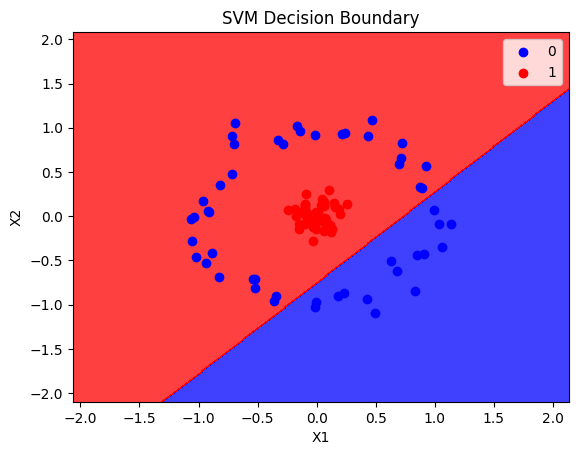

In [75]:
# plot_decision_boundary(X_test, y_test, classifier)
plot_decision_boundary(X, y, classifier)

In [76]:
# Transform data from 2D to 3D
def plot_3d_plot(X, y):
    # 1st square and .sum(1) means Sum along rows ([1,4]=5, [4,9]=13) then np.exp(-(5,13))
    r = np.exp(-(X**2).sum(1)) # z-axis, transformation creates a “bump” shape: Center:high,Outer:low
    ax = plt.subplot(projection='3d') 
    ax.scatter3D(X[:,0],X[:,1], r, c=y, s=100, cmap='bwr')  # Plot 3D points
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

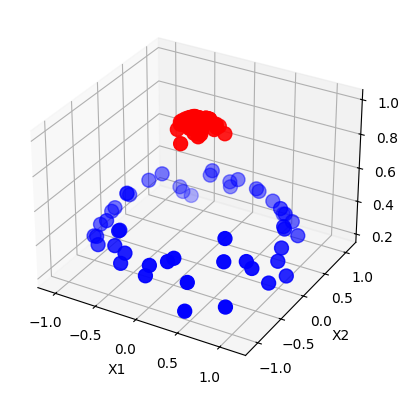

In [66]:
plot_3d_plot(X,y)

# Radial Based Function(RBF) Kernel

In [84]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train,y_train)
y_pred = rbf_classifier.predict(X_test)

In [85]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_42629/640004044.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=(zero_one_colourmap)(i), label=j)


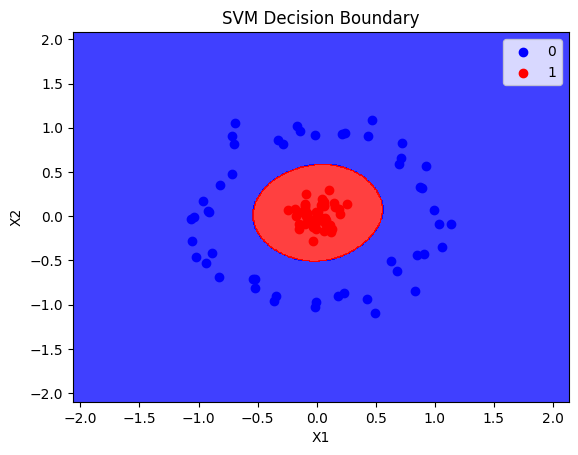

In [86]:
plot_decision_boundary(X, y, rbf_classifier)

# Polynomial Kernel

In [97]:
# poly_classifier = SVC(kernel='poly',degree=2) 
poly_classifier = SVC(kernel='poly',degree=3)

poly_classifier.fit(X_train,y_train)
y_pred = poly_classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.45

/tmp/ipykernel_42629/640004044.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c=(zero_one_colourmap)(i), label=j)


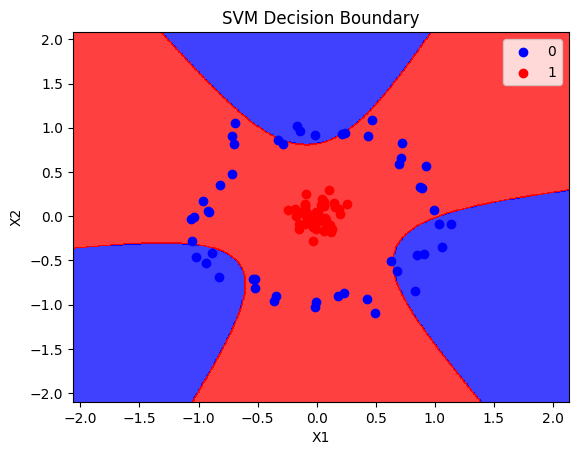

In [98]:
plot_decision_boundary(X, y, poly_classifier)

In [112]:
X

array([[ 8.76030076e-01,  3.27869753e-01],
       [-9.93123538e-02,  1.05511254e-01],
       [-3.63052045e-01, -9.61299215e-01],
       [-6.96220334e-01,  8.13161024e-01],
       [-5.16215218e-02, -4.06799281e-02],
       [ 2.49829858e-03, -4.83748959e-03],
       [-1.81675012e-01,  7.82237583e-02],
       [-3.46109937e-01, -9.00092969e-01],
       [ 4.72245194e-01,  1.08800882e+00],
       [ 1.42479976e-02,  4.63097572e-02],
       [ 1.29507780e-01, -1.44072134e-01],
       [ 5.23351862e-02,  1.66975677e-01],
       [ 6.48791787e-02, -1.70538533e-01],
       [ 2.17497103e-01,  9.26442639e-01],
       [-1.00385437e-01, -8.88341647e-02],
       [-6.94655446e-03,  4.52585612e-02],
       [ 9.91293819e-01,  6.83115441e-02],
       [-1.65623550e-02, -1.03109002e+00],
       [ 1.14279532e-01, -9.77556645e-02],
       [ 8.47274360e-01, -4.37466921e-01],
       [ 1.04136791e-01, -1.02116658e-01],
       [ 3.71433470e-02, -4.28529454e-02],
       [ 4.94718494e-01, -1.09853067e+00],
       [-1.

In [104]:
np.exp(-(X**2)).sum(1) # sum along rows

array([1.36228295, 1.97911465, 1.27340031, 1.13208348, 1.99568528,
       1.99997036, 1.96143266, 1.33188848, 1.10622699, 1.99765472,
       1.96282477, 1.96976898, 1.967135  , 1.37768024, 1.98211292,
       1.99790551, 1.36965722, 1.34509308, 1.97751444, 1.31360921,
       1.97884049, 1.99678663, 1.08206519, 1.3225923 , 1.10014544,
       1.97014267, 1.26875853, 1.39137938, 1.36839398, 1.25496337,
       1.99706285, 1.14649319, 1.97369077, 1.99412314, 1.95608327,
       1.3359597 , 1.99237002, 1.99185064, 1.96612309, 1.37467777,
       1.44880943, 1.96858023, 1.98236676, 1.95705548, 1.43149246,
       1.1345057 , 1.99807943, 1.95786276, 1.03785706, 0.98611642,
       1.97187569, 1.30549078, 1.2079645 , 1.43462562, 1.9969046 ,
       1.35460368, 1.41541397, 1.98291726, 1.97157889, 1.34907115,
       1.2434086 , 1.91700849, 1.97919653, 1.99488625, 1.32147651,
       1.25040609, 1.30039226, 1.98861786, 1.27529806, 1.98187557,
       1.92156571, 1.16206556, 1.9830984 , 1.9305888 , 1.99839

In [105]:
X_new = np.exp(-(X**2))

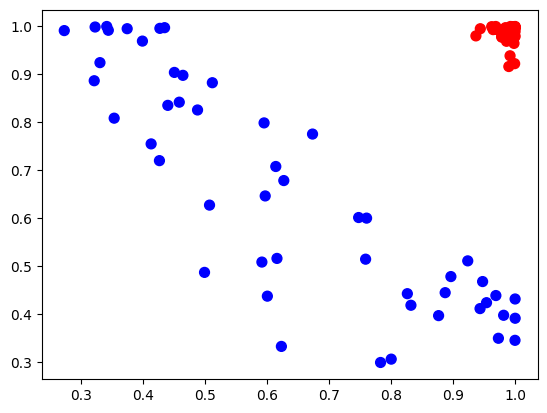

In [106]:
plt.scatter(X_new[:,0], X_new[:,1], c=y, s=50, cmap='bwr')